# FFT Pricer — Effect of α and N on Call Prices
This notebook runs `fft_pricer` across multiple damping factors `α` and grid sizes `N`, and plots the results to visualize the effect of adaptive dampening.

In [20]:
import numpy as np
from numpy.typing import NDArray

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Callable, Mapping

import unittest
from scipy.stats import norm
import sys
import os

In [21]:
def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    """
    Calculates exact Black-Scholes prices to serve as Ground Truth.
    """
    if T <= 1e-8:
        return np.maximum(S - K, 0) if option_type == 'call' else np.maximum(K - S, 0)

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def check_convexity(prices, strikes, tolerance=1e-6):
    """
    Verifies convexity on a non-uniform (log-spaced) strike grid.

    The FFT produces log-spaced strikes, so the symmetric second difference
    P[i-1] - 2*P[i] + P[i+1] approximates d²C/d(logK)², NOT d²C/dK².
    For deep ITM calls K*dC/dK ≈ -K (large negative), making the symmetric
    formula negative even for perfectly convex prices.

    Correct no-arbitrage condition for an arbitrary grid:
        wa*C(Ka) + wc*C(Kc) - C(Kb) >= 0
    where wa = (Kc-Kb)/(Kc-Ka),  wc = (Kb-Ka)/(Kc-Ka)
    """
    Ka, Kb, Kc = strikes[:-2], strikes[1:-1], strikes[2:]
    Ca, Cb, Cc = prices[:-2],  prices[1:-1],  prices[2:]
    wa = (Kc - Kb) / (Kc - Ka)
    wc = (Kb - Ka) / (Kc - Ka)
    butterfly_cost = wa * Ca + wc * Cc - Cb
    return np.all(butterfly_cost >= -tolerance)

def cf_bs(u: NDArray[np.complex128], params: dict[str, float]) -> NDArray[np.complex128]:
    S0    = params["S0"]
    r     = params["r"]
    sigma = params["sigma"]
    T     = params["T"]
    mu = np.log(S0) + (r - 0.5 * sigma**2) * T
    return np.exp(1j * u * mu - 0.5 * sigma**2 * u**2 * T)

In [22]:
def fft_pricer(
    cf: Callable[[np.ndarray, Mapping[str, float]], np.ndarray],
    params: Mapping[str, float],
    alpha: float = None,
    N: int = 2**12,
    eta: float = 0.25,
    psi_override: np.ndarray = None
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Carr-Madan FFT pricer for European call options.
    When alpha=None, an adaptive sweep selects the first alpha in
    [0.25, 0.50, ..., 4.00] that produces finite, non-negative prices.
    """

    if alpha is None:
        S0   = params["S0"]
        win  = lambda K: (K > S0 * 0.5) & (K < S0 * 2.0)
        for _alpha in np.arange(0.25, 4.25, 0.25):
            _K, _v = fft_pricer(cf, params, alpha=_alpha, N=N, eta=eta,
                                psi_override=psi_override)
            w = win(_K)
            if np.all(np.isfinite(_v[w])) and np.all(_v[w] >= 0):
                return _K, _v
        return fft_pricer(cf, params, alpha=1.5, N=N, eta=eta,
                          psi_override=psi_override)

    r  = params["r"]
    T  = params["T"]

    j = np.arange(N)
    v = j * eta
    u = v - 1j * (alpha + 1.0)

    if psi_override is None:
        phi_vals = cf(u, params)
        discount = np.exp(-r * T)
        denom    = alpha**2 + alpha - v**2 + 1j * (2 * alpha + 1) * v
        psi      = discount * phi_vals / denom
    else:
        psi = psi_override

    lambd = 2 * np.pi / (N * eta)
    b     = 0.5 * N * lambd
    m     = np.arange(N)
    k     = -b + m * lambd
    K     = np.exp(k)

    w      = np.ones(N)
    w[0]   = 0.5
    w[-1]  = 0.5
    w     *= eta

    fft_input  = np.exp(1j * b * v) * psi * w
    fft_output = np.fft.fft(fft_input)
    values     = np.exp(-alpha * k) * fft_output.real / np.pi

    return K, values

In [23]:
# ── Parameters ────────────────────────────────────────────────────────────────
params = {
    "S0":    100.0,
    "r":     0.05,
    "T":     1.0,
    "sigma": 0.2
}

ALPHAS = [0.25, 0.75, 1.25, 2.0, 4.0]   # damping factors to test
NS     = [256, 1024, 4096]               # grid sizes to test
ETA    = 0.25

S0   = params["S0"]
mask = lambda K: (K > S0 * 0.4) & (K < S0 * 1.8)

# Analytical benchmark on a fine strike grid
K_bench  = np.linspace(S0 * 0.4, S0 * 1.8, 500)
bs_bench = black_scholes_price(
    S0, K_bench, params["T"], params["r"], params["sigma"], "call"
)

## 1 — Effect of α (fixed N = 4096)

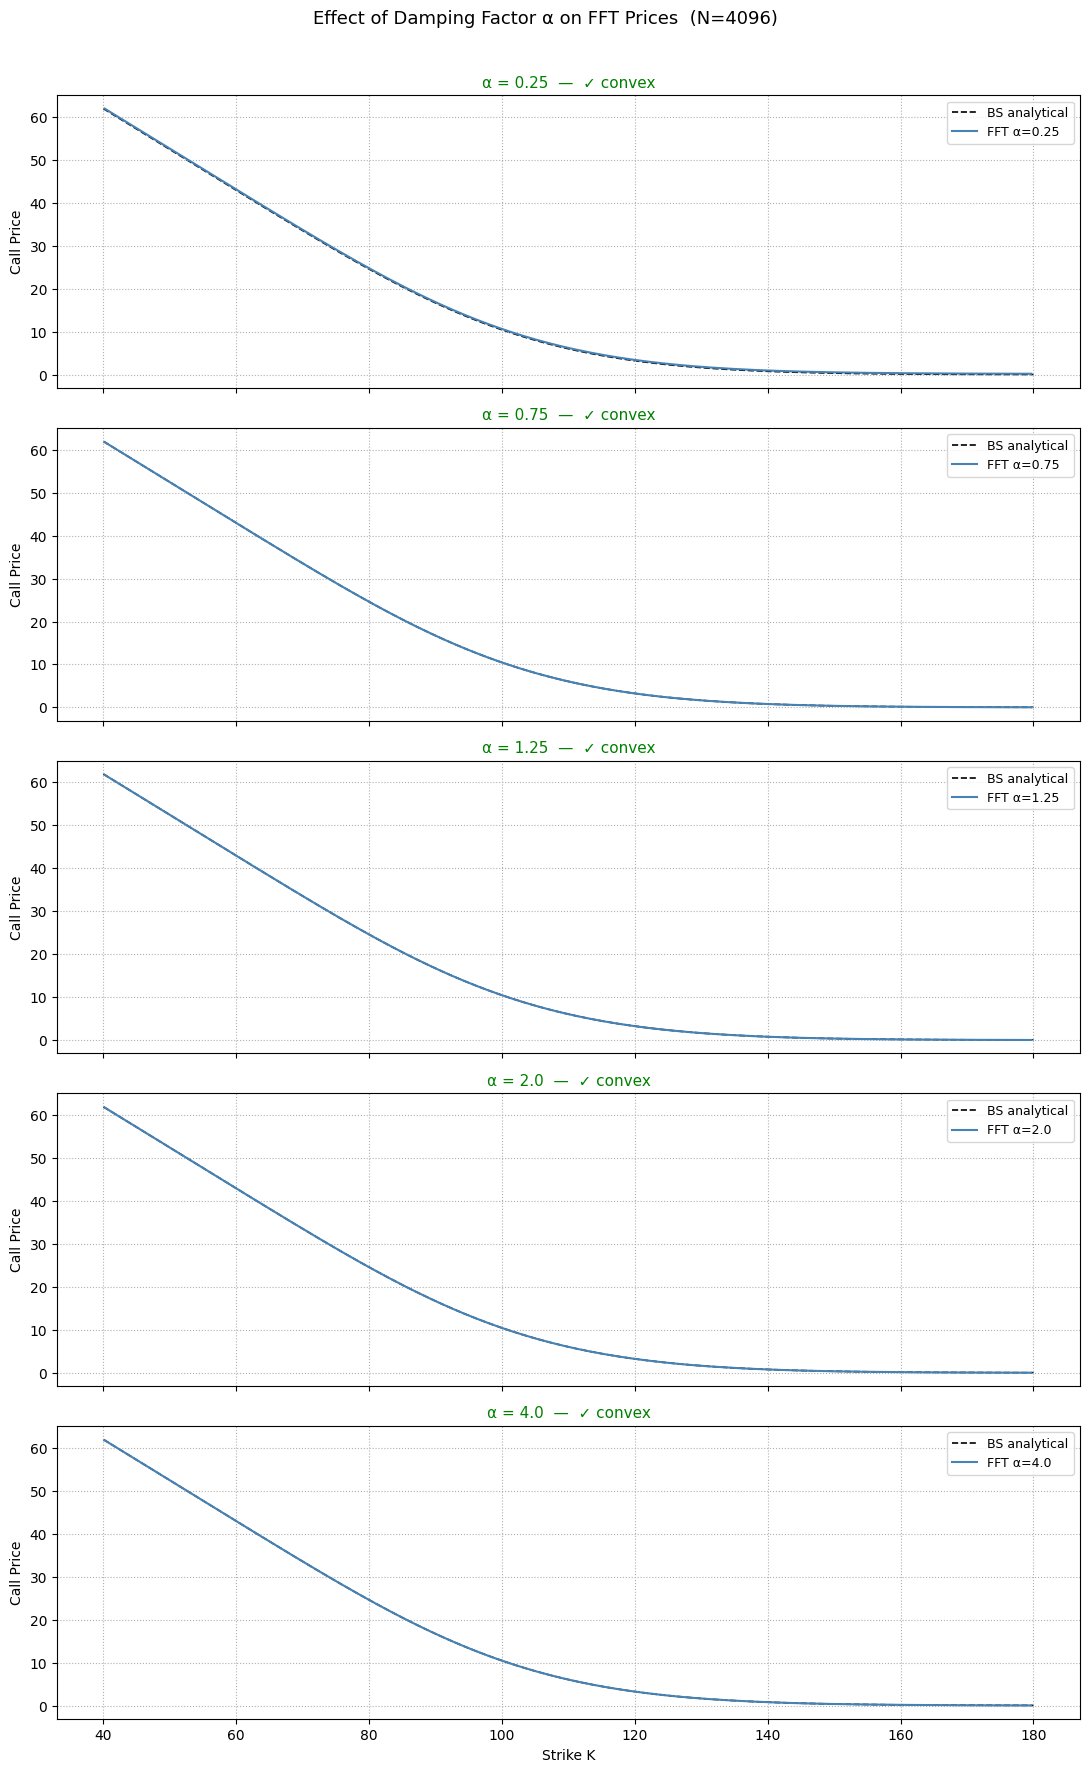

In [24]:
fig, axes = plt.subplots(len(ALPHAS), 1, figsize=(11, 3.5 * len(ALPHAS)), sharex=True)

for ax, alpha in zip(axes, ALPHAS):
    K, prices      = fft_pricer(cf_bs, params, alpha=alpha, N=4096, eta=ETA)
    K_c            = K[mask(K)]
    prices_c       = prices[mask(K)]
    is_convex      = check_convexity(prices_c, K_c, tolerance=1e-6)
    color          = "green" if is_convex else "red"
    status         = "✓ convex" if is_convex else "✗ convexity violated"

    ax.plot(K_bench, bs_bench, "k--", linewidth=1.2, label="BS analytical", zorder=1)
    ax.plot(K_c, prices_c, color="steelblue", linewidth=1.5, label=f"FFT α={alpha}", zorder=2)
    ax.set_title(f"α = {alpha}  —  {status}", color=color, fontsize=11)
    ax.set_ylabel("Call Price")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":")

axes[-1].set_xlabel("Strike K")
fig.suptitle("Effect of Damping Factor α on FFT Prices  (N=4096)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2 — Effect of N (fixed α = 1.25)

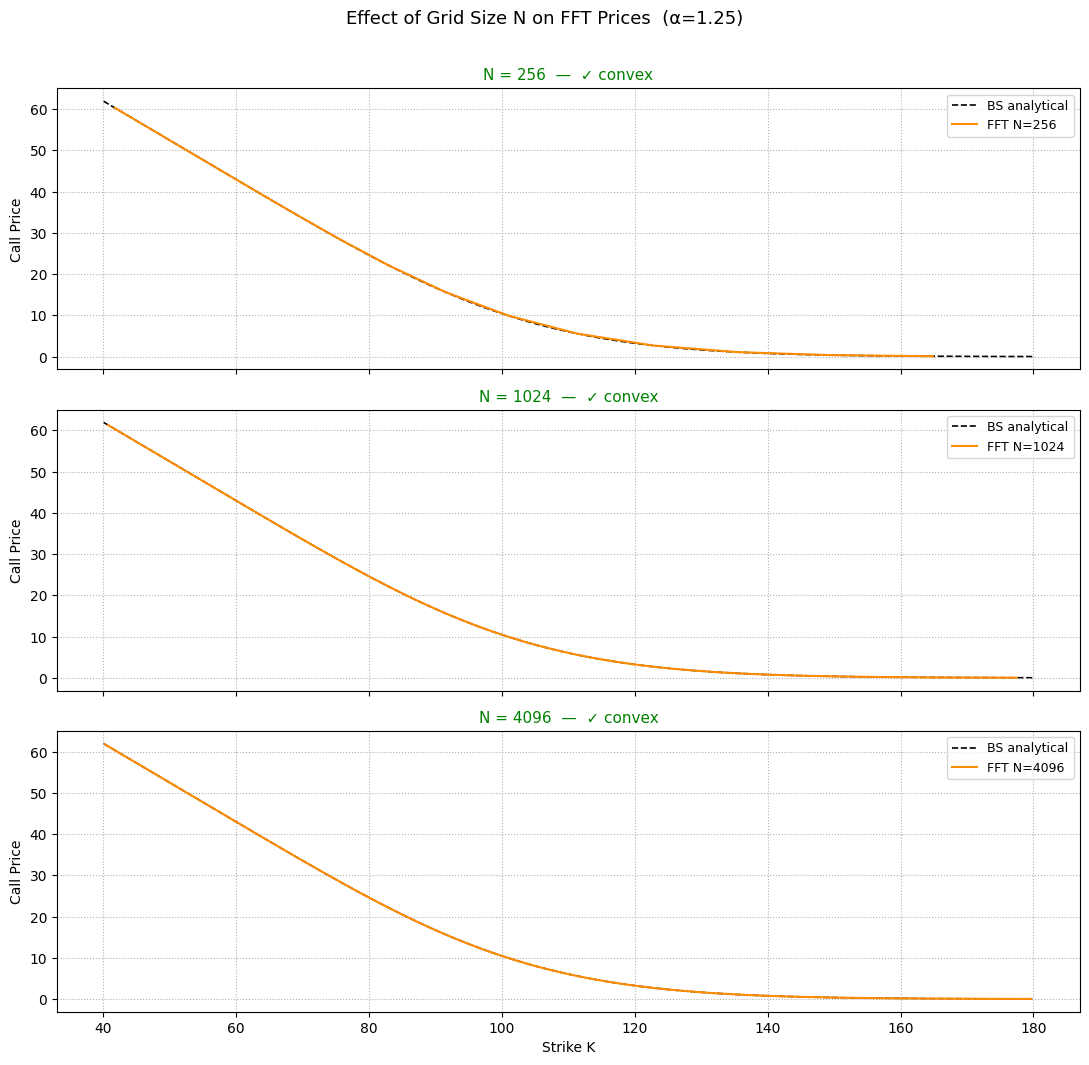

In [25]:
fig, axes = plt.subplots(len(NS), 1, figsize=(11, 3.5 * len(NS)), sharex=True)

for ax, N in zip(axes, NS):
    K, prices      = fft_pricer(cf_bs, params, alpha=1.25, N=N, eta=ETA)
    K_c            = K[mask(K)]
    prices_c       = prices[mask(K)]
    is_convex      = check_convexity(prices_c, K_c, tolerance=1e-6)
    color          = "green" if is_convex else "red"
    status         = "✓ convex" if is_convex else "✗ convexity violated"

    ax.plot(K_bench, bs_bench, "k--", linewidth=1.2, label="BS analytical", zorder=1)
    ax.plot(K_c, prices_c, color="darkorange", linewidth=1.5, label=f"FFT N={N}", zorder=2)
    ax.set_title(f"N = {N}  —  {status}", color=color, fontsize=11)
    ax.set_ylabel("Call Price")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=":")

axes[-1].set_xlabel("Strike K")
fig.suptitle("Effect of Grid Size N on FFT Prices  (α=1.25)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3 — Heatmap: Max Absolute Error vs α and N

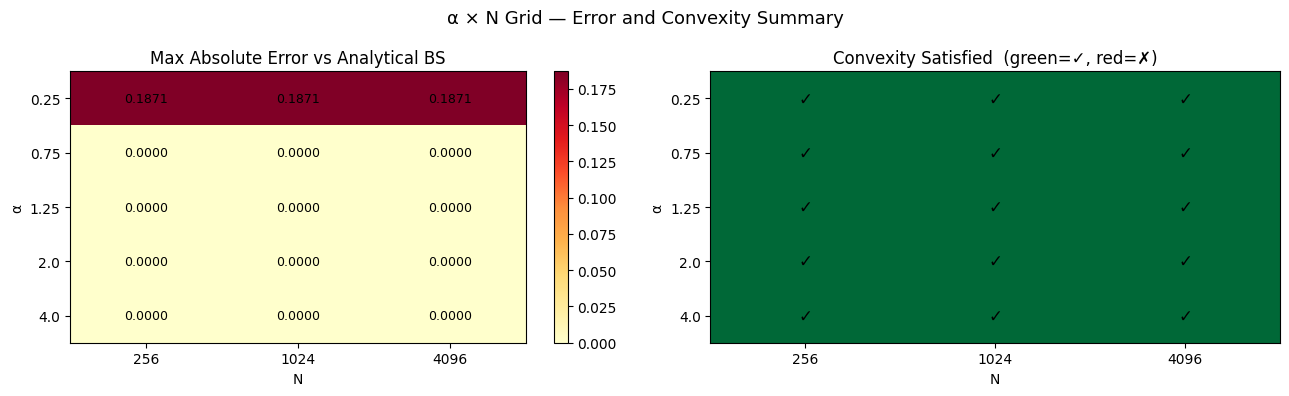

In [26]:
errors    = np.zeros((len(ALPHAS), len(NS)))
convexity = np.zeros((len(ALPHAS), len(NS)), dtype=bool)

for i, alpha in enumerate(ALPHAS):
    for j, N in enumerate(NS):
        K, prices  = fft_pricer(cf_bs, params, alpha=alpha, N=N, eta=ETA)
        K_c        = K[mask(K)]
        prices_c   = prices[mask(K)]
        bs_c       = black_scholes_price(
            S0, K_c, params["T"], params["r"], params["sigma"], "call"
        )
        errors[i, j]    = np.max(np.abs(prices_c - bs_c))
        convexity[i, j] = check_convexity(prices_c, K_c, tolerance=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Max error heatmap
im0 = axes[0].imshow(errors, aspect="auto", cmap="YlOrRd")
axes[0].set_xticks(range(len(NS)));     axes[0].set_xticklabels(NS)
axes[0].set_yticks(range(len(ALPHAS))); axes[0].set_yticklabels(ALPHAS)
axes[0].set_xlabel("N"); axes[0].set_ylabel("α")
axes[0].set_title("Max Absolute Error vs Analytical BS")
plt.colorbar(im0, ax=axes[0])
for i in range(len(ALPHAS)):
    for j in range(len(NS)):
        axes[0].text(j, i, f"{errors[i,j]:.4f}", ha="center", va="center", fontsize=9)

# Convexity heatmap
im1 = axes[1].imshow(convexity.astype(float), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
axes[1].set_xticks(range(len(NS)));     axes[1].set_xticklabels(NS)
axes[1].set_yticks(range(len(ALPHAS))); axes[1].set_yticklabels(ALPHAS)
axes[1].set_xlabel("N"); axes[1].set_ylabel("α")
axes[1].set_title("Convexity Satisfied  (green=✓, red=✗)")
for i in range(len(ALPHAS)):
    for j in range(len(NS)):
        axes[1].text(j, i, "✓" if convexity[i,j] else "✗", ha="center", va="center", fontsize=12)

fig.suptitle("α × N Grid — Error and Convexity Summary", fontsize=13)
plt.tight_layout()
plt.show()

## 4 — Adaptive α selection

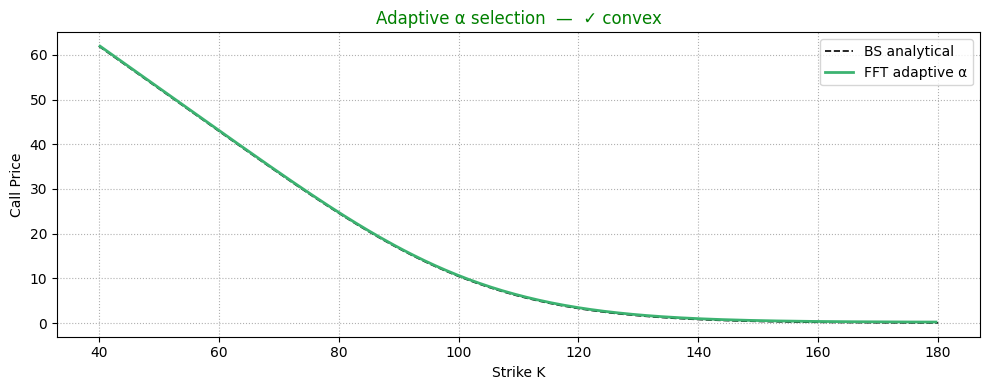

In [27]:
K_auto, prices_auto = fft_pricer(cf_bs, params)  # alpha=None → adaptive
K_c                 = K_auto[mask(K_auto)]
prices_c            = prices_auto[mask(K_auto)]
is_convex           = check_convexity(prices_c, K_c, tolerance=1e-6)

plt.figure(figsize=(10, 4))
plt.plot(K_bench,  bs_bench,  "k--", linewidth=1.2, label="BS analytical")
plt.plot(K_c,      prices_c,  color="mediumseagreen", linewidth=2, label="FFT adaptive α")
plt.title(
    f"Adaptive α selection  —  {'✓ convex' if is_convex else '✗ convexity violated'}",
    color="green" if is_convex else "red"
)
plt.xlabel("Strike K")
plt.ylabel("Call Price")
plt.legend()
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()